In [32]:
x, y, z, sigma, rho, b= var('x y z sigma rho beta')
dx = sigma * (y - x)
dy = x * (rho-z) - y
dz = x * y - beta * z
assume(sigma>0., beta>0., sigma > 0.)

In [39]:
sols = solve([dx, dy, dz], x, y,z)
pretty_print(sols)

[[x == sqrt(beta*rho - beta), y == sqrt(beta*rho - beta), z == rho - 1], [x == -sqrt(beta*rho - beta), y == -sqrt(beta*rho - beta), z == rho - 1], [x == 0, y == 0, z == 0]]

In [43]:
J = jacobian([dx,dy,dz],[x,y,z])
print(J)

[ -sigma   sigma       0]
[rho - z      -1      -x]
[      y       x   -beta]


In [44]:
J0 = J.subs(sols[2])
print(J0)

[-sigma  sigma      0]
[   rho     -1      0]
[     0      0  -beta]


In [46]:
eJ0 = J0.eigenvalues();
pretty_print(eJ0)

[-1/2*sigma - 1/2*sqrt(2*(2*rho - 1)*sigma + sigma^2 + 1) - 1/2,
 -1/2*sigma + 1/2*sqrt(2*(2*rho - 1)*sigma + sigma^2 + 1) - 1/2,
 -beta]

In [48]:
pretty_print(solve(eJ0[1], rho))


[rho == 1]

In [49]:
assume(rho > 1)

In [50]:
J1 = J.subs(sols[1])
pretty_print(J1)

[                -sigma                  sigma                      0]
[                     1                     -1  sqrt(beta*rho - beta)]
[-sqrt(beta*rho - beta) -sqrt(beta*rho - beta)                  -beta]

In [106]:
λ = var('λ')
carpol = (J1 - matrix.identity(3)*λ).determinant()
test = SR[λ](carpol)
pretty_print(test)

-(beta*rho + (beta + λ)*(λ + 1) - beta)*(sigma + λ) - (beta*rho - beta)*sigma + (beta + λ)*sigma

In [117]:
dcarpol = diff(carpol, λ )
print ( dcarpol.parent() )
pretty_print(dcarpol)

Symbolic Ring


-beta*rho - (beta + 2*λ + 1)*(sigma + λ) - (beta + λ)*(λ + 1) + beta + sigma

In [122]:
SS = solve(dcarpol, λ )
pretty_print(SS)

[λ == -1/3*beta - 1/3*sigma - 1/3*sqrt(beta^2 - 3*beta*rho - (beta - 2)*sigma + sigma^2 + 2*beta + 1) - 1/3, λ == -1/3*beta - 1/3*sigma + 1/3*sqrt(beta^2 - 3*beta*rho - (beta - 2)*sigma + sigma^2 + 2*beta + 1) - 1/3]

In [135]:
S3 = carpol.subs(SS[1]).subs(sigma=10, beta = 8/3)
pretty_print(S3)

-1/729*((3*sqrt(-8*rho + 961/9) - 17)*(3*sqrt(-8*rho + 961/9) - 32) + 216*rho - 216)*(3*sqrt(-8*rho + 961/9) + 49) - 80/3*rho + 10/3*sqrt(-8*rho + 961/9) + 70/9

In [146]:
r1 = S3.find_root(1,3)

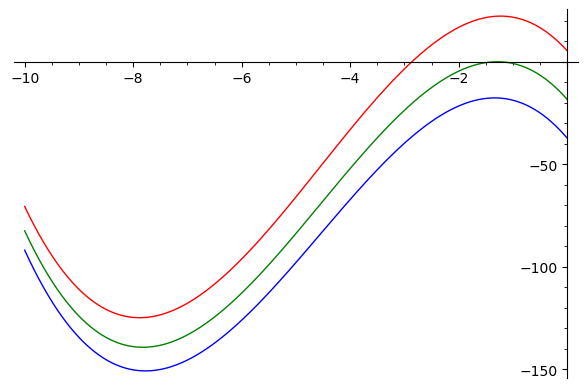

In [151]:
P1 = plot(carpol.subs(sigma=10, beta = 8/3, rho = 0.9), -10, 0 , color='red')
P2 = plot(carpol.subs(sigma=10, beta = 8/3, rho = 1.7), -10, 0, color = 'blue' )
P3 = plot(carpol.subs(sigma=10, beta = 8/3, rho = r1), -10, 0, color = 'green')
P1 + P2 + P3

In [165]:
𝜔 = var('𝜔')
eqw = carpol.subs( λ = - sqrt(-1)* 𝜔)
pretty_print(eqw.expand())

-2*beta*rho*sigma + I*beta*rho*𝜔 + I*beta*sigma*𝜔 + beta*𝜔^2 + sigma*𝜔^2 - I*𝜔^3 + 2*beta*sigma + 𝜔^2

In [167]:
SOL = solve([real_part(eqw), imag_part(eqw)], [rho, 𝜔])
pretty_print(SOL)

[[rho == 1, 𝜔 == 0], [rho == -((beta + 3)*sigma + sigma^2)/(beta - sigma + 1), 𝜔 == -sqrt(2)*sqrt(-(beta*sigma^2 + beta*sigma)/(beta - sigma + 1))], [rho == -((beta + 3)*sigma + sigma^2)/(beta - sigma + 1), 𝜔 == sqrt(2)*sqrt(-(beta*sigma^2 + beta*sigma)/(beta - sigma + 1))]]

In [178]:
rh = SOL[1][0].subs(sigma=10, beta = 8/3)

In [192]:
print(rh)

rho == (470/19)


In [191]:
print(RDF(rh.rhs()))

24.736842105263158
